In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

In [2]:
df = pd.read_pickle('../data/cleaned-data/cleaned.pkl')

In [3]:
def data_process(df):
    data = df.copy()
    return data.set_index('order-date').sort_index()

In [4]:
df = data_process(df)

In [5]:
# def monthly_profit(df, from_, to_):
#     monthly_data = df.loc[str(from_):str(to_)]
#     profit = monthly_data['profit'].resample('ME').sum()
#     sns.lineplot(profit)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


def monthly_profit(df, from_, to_):
    # 1. Slice and resample
    monthly_data = df.loc[str(from_) : str(to_)]
    profit = monthly_data["profit"].resample("ME").sum()

    # 2. Setup theme & clear previous figures (important for Streamlit re-renders)
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)

    # 3. Line plot with custom accents
    sns.lineplot(
        x=profit.index,
        y=profit.values,
        ax=ax,
        color="#2563EB",  # Vibrant Streamlit-friendly blue
        linewidth=2.5,
        marker="o",
        markersize=6,
        markerfacecolor="#FFFFFF",
        markeredgewidth=2,
        markeredgecolor="#2563EB",
    )

    # Shaded fill under the line
    ax.fill_between(profit.index, profit.values, color="#2563EB", alpha=0.1)

    # 4. Title & Labels
    ax.set_title(
        f"Monthly Profit ({from_} to {to_})",
        fontsize=13,
        fontweight="bold",
        pad=12,
        color="#1E293B",
    )
    ax.set_xlabel("")  # Clean x-axis label (date tick labels are self-explanatory)
    ax.set_ylabel(
        "Profit ($)", fontsize=10, fontweight="bold", color="#475569"
    )

    # 5. Currency formatting on Y-axis
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

    # 6. Clean grid & borders
    ax.tick_params(colors="#64748B", labelsize=9)
    ax.grid(True, linestyle="--", alpha=0.4, color="#CBD5E1")
    sns.despine(top=True, right=True)

    plt.tight_layout()

    # 7. Close figure internally to manage Streamlit memory
    plt.close(fig)

    return fig

In [7]:
from datetime import date

In [8]:
from_ = date(2014, 1, 3)
to_ = date(2016, 12, 30)

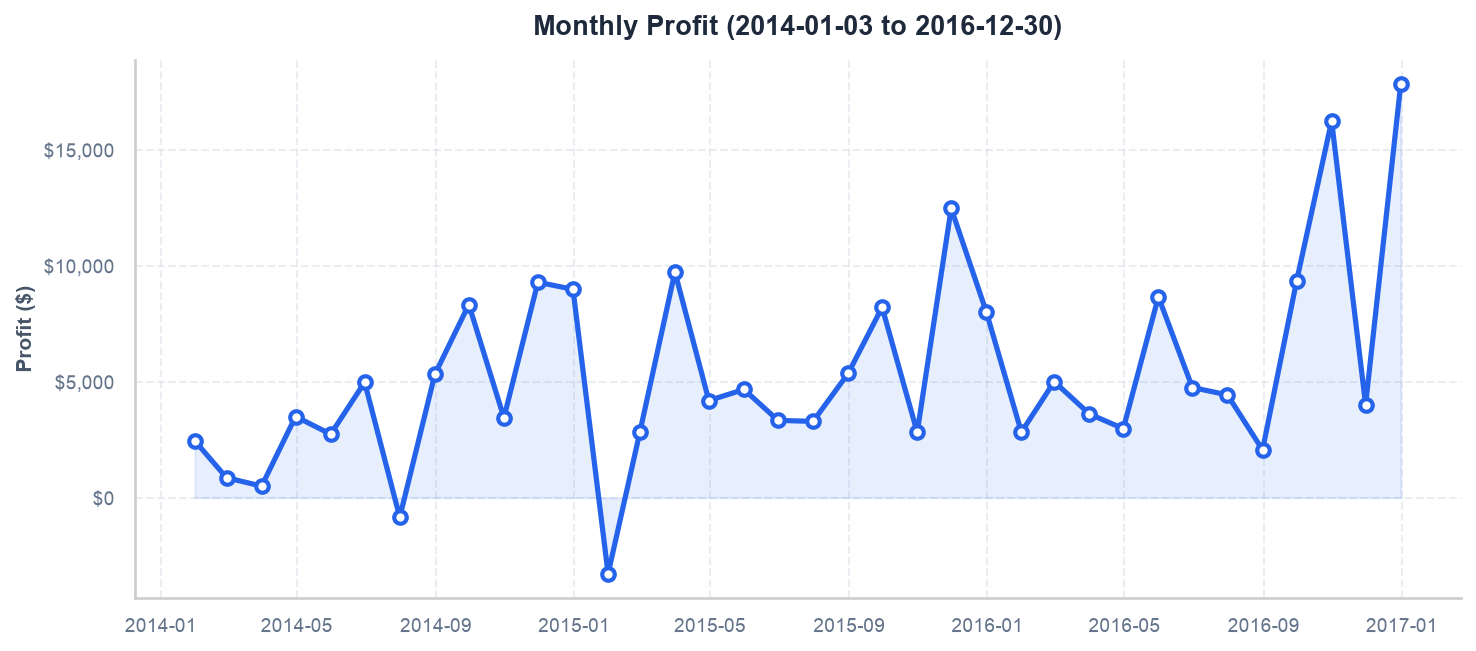

In [9]:
monthly_profit(df, from_, to_)